In [19]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
import matplotlib.gridspec as gridspec
from scipy import stats
import xarray as xr
plt.rcParams.update({'font.size': 12})

In [3]:
mydir = '../processed_netcdf/'
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nm = 12
alph = ['(a)','(b)','(c)','(d)']
myhemi = ['SH','NH']
smallhemi=['sh','nh']
gencolours = ['blue','red','green','black']

In [4]:
def add_trend_stats_to_ds (ds,var,varname): #var = is a data array

    array_names = ['slope', 'intercept','r_value', 'p_value']
    array_names = [varname+'_'+f for f in array_names]
    ndim = var.shape
    mystats = []
    
    if len(ndim) == 3:
        for i in range(ndim[0]):
            for j in range(ndim[2]):
                ydata = var[i,:,j].values
                xdata = ds.year.values[:len(ydata)]
                slope, intercept, r_value, p_value, _ = stats.linregress(xdata[~np.isnan(ydata)], ydata[~np.isnan(ydata)])
                mystats.append([slope, intercept, r_value, p_value])
        mystats = np.asarray(mystats).reshape([ndim[0],ndim[2],4])
        for a, arr_name in enumerate(array_names):
            ds[arr_name] = xr.DataArray(mystats[:,:,a],dims=['name','month'])
  
    elif len(ndim) == 2:
        for i in range(ndim[0]):
                ydata = var[i,:].values
                xdata = ds.year.values
                if np.count_nonzero(np.isnan(ydata))>1:
                    slope, r_value, p_value = np.nan, np.nan, np.nan
                else:
                    slope, intercept, r_value, p_value, _ = stats.linregress(xdata[~np.isnan(ydata)], ydata[~np.isnan(ydata)])
                mystats.append([slope, intercept, r_value, p_value])
        mystats = np.asarray(mystats).reshape([ndim[0],4])
        for a, arr_name in enumerate(array_names):
            ds[arr_name] = xr.DataArray(mystats[:,a],dims=['name'])
  
    return ds

In [8]:
# trends from piControl
piCtrend_dict = {} 
model_name = xr.open_dataset(mydir+'processed_CMIP6_sia_ssp245_r1.nc').name        
myfiles = [mydir+'/piControl/CMIP6_sia_sh/'+f for f in os.listdir(mydir+'/piControl/CMIP6_sia_sh/')]
for n,file in enumerate(myfiles):
    ds = xr.open_dataset(file,decode_times=False)
    if len(ds.sia.shape) ==3:
        sia = ds.sia[:,0,0].values
    else:
        sia = ds.sia.values

    if file.split('_')[5] in [f.strip().split('_')[0] for f in model_name.values]:
        if len(sia)>nm*40:
            ny = int(len(sia)/nm)
            sia_ym = np.reshape(sia[:ny*nm],(ny,nm))
    
            sep_slopes = []
            feb_slopes = []
            for y in range(ny-39):
                feb_slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(40),sia_ym[y:40+y,1])
                sep_slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(40),sia_ym[y:40+y,8])

                sep_slopes.append(10.*sep_slope)
                feb_slopes.append(10.*feb_slope)
                
            piCtrend_dict[file.split('_')[5]] = [feb_slopes,sep_slopes]

In [15]:
ensemble_ds = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_ssp245_allr.nc').sel(year=slice('1979','2018'))

ensemble_ds = add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_sh, 'sia_sh')
ensemble_ds = add_trend_stats_to_ds (ensemble_ds, ensemble_ds.gmst, 'gmst')
ensemble_ds = add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_nh.mean(dim='month'), 'sia_nh_annmean')
ensemble_ds = add_trend_stats_to_ds (ensemble_ds, ensemble_ds.sia_sh.mean(dim='month'), 'sia_sh_annmean')
print(ensemble_ds.name.values)

['ACCESS-CM2_r1i1p1f1' 'ACCESS-ESM1-5_r1i1p1f1' 'AWI-CM-1-1-MR_r1i1p1f1'
 'BCC-CSM2-MR_r1i1p1f1' 'CAMS-CSM1-0_r1i1p1f1' 'CAMS-CSM1-0_r2i1p1f1'
 'CESM2-WACCM_r1i1p1f1' 'CESM2_r1i1p1f1' 'CNRM-CM6-1_r1i1p1f2'
 'CNRM-ESM2-1_r1i1p1f2' 'CanESM5_r10i1p1f1' 'CanESM5_r1i1p1f1'
 'CanESM5_r2i1p1f1' 'CanESM5_r3i1p1f1' 'CanESM5_r4i1p1f1'
 'CanESM5_r5i1p1f1' 'CanESM5_r6i1p1f1' 'CanESM5_r7i1p1f1'
 'CanESM5_r8i1p1f1' 'CanESM5_r9i1p1f1' 'EC-Earth3-Veg_r1i1p1f1'
 'EC-Earth3-Veg_r2i1p1f1' 'EC-Earth3-Veg_r4i1p1f1' 'EC-Earth3_r12i1p1f1'
 'EC-Earth3_r14i1p1f1' 'EC-Earth3_r16i1p1f1' 'EC-Earth3_r17i1p1f1'
 'EC-Earth3_r18i1p1f1' 'EC-Earth3_r19i1p1f1' 'EC-Earth3_r1i1p1f1'
 'EC-Earth3_r20i1p1f1' 'EC-Earth3_r21i1p1f1' 'EC-Earth3_r22i1p1f1'
 'EC-Earth3_r24i1p1f1' 'EC-Earth3_r2i1p1f1' 'EC-Earth3_r4i1p1f1'
 'FGOALS-f3-L_r1i1p1f1' 'FGOALS-g3_r1i1p1f1' 'GFDL-CM4_r1i1p1f1'
 'GFDL-ESM4_r1i1p1f1' 'HadGEM3-GC31-LL_r1i1p1f3' 'INM-CM4-8_r1i1p1f1'
 'INM-CM5-0_r1i1p1f1' 'IPSL-CM6A-LR_r1i1p1f1' 'IPSL-CM6A-LR_r2i1p1f1'
 'MIROC-

In [10]:
obs_ds =  xr.open_dataset(mydir+'processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2018'))
obs_ds = add_trend_stats_to_ds (obs_ds, obs_ds.sia_nh, 'sia_nh')
obs_ds = add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')
obs_ds = add_trend_stats_to_ds (obs_ds, obs_ds.sia_nh.mean(dim='month'), 'sia_nh_annmean')
obs_ds = add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh.mean(dim='month'), 'sia_sh_annmean')
obs_ds = add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh.sel(year=slice('1979','2014')), 'sia_sh_1979to2014')   

In [11]:
#NOAA - 1971-2000 climatology
#Berkeley - 1951-1980 climatology
#HadCRUT - 1961 - 1990 climatology
#GISTEMP - 1951 - 1980 climatology
array_names = ['slope', 'intercept', 'r_value', 'p_value', 'std_err']
array_names = ['gmst_'+f for f in array_names]
onames = ['noaa','gistemp','berkeley','HadCRUT']
anomperiodst = ['1880','1850','1850','1850'] 
gmst_stats = np.zeros([4,5])
for o,oname in enumerate(onames):
    ds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice('1979','2018'))
    anompds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice(anomperiodst[o],'1900')).tas_ano[:,0,0]
    
    da = ds.tas_ano[:,0,0]
    if len(da.shape) > 1:
        da = da[:,0]
        anompds = anompds[:,0]
    
    da.values = da.values - anompds.mean(dim='time').values
    #print(anompds)
    
    gmst_stats[o,:] = stats.linregress(np.arange(len(ds.time)),da)

for a, arr_name in enumerate(array_names):
    if a ==0:
        var1 = xr.DataArray(gmst_stats[:,a],dims=['name'])
        gmst_ds = var1.to_dataset(name = arr_name)
    else:
        gmst_ds[arr_name] = xr.DataArray(gmst_stats[:,a],dims=['name'])
gmst_ds['name'] = onames
print(gmst_ds)

<xarray.Dataset>
Dimensions:         (name: 4)
Coordinates:
  * name            (name) <U8 'noaa' 'gistemp' 'berkeley' 'HadCRUT'
Data variables:
    gmst_slope      (name) float64 0.01692 0.01748 0.01875 0.01759
    gmst_intercept  (name) float64 0.3798 0.3732 0.4071 0.3223
    gmst_r_value    (name) float64 0.9084 0.9072 0.921 0.9121
    gmst_p_value    (name) float64 5.743e-16 7.208e-16 3.809e-17 2.689e-16
    gmst_std_err    (name) float64 0.001263 0.001314 0.001286 0.001282


In [12]:
corr_nh = []
corr_sh = []

for o,oname in enumerate(onames):
    ds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice('1979','2018'))
    anompds = xr.open_dataset('../processed_netcdf/GMST_'+oname+'_yearly.nc').sel(time=slice(anomperiodst[o],'1900')).tas_ano[:,0,0]
    
    da = ds.tas_ano[:,0,0]
    if len(da.shape) > 1:
        da = da[:,0]
        anompds = anompds[:,0]
    
    da.values = da.values - anompds.mean(dim='time').values
    
    
    for sio in np.arange(3):
        xdata = da.values#-np.arange(40)*gmst_ds.gmst_slope.isel(name=0).values + gmst_ds.gmst_intercept.isel(name=0).values
        bestfity = obs_ds.isel(name=sio).sia_nh_annmean_slope.values*np.arange(40) + obs_ds.isel(name=sio).sia_nh_annmean_intercept.values
        corr, p = stats.pearsonr(xdata,obs_ds.sia_nh.mean(dim='month').isel(name=sio))#-bestfity)
        corr_nh.append(corr)
        bestfity = obs_ds.isel(name=sio).sia_sh_annmean_slope.values*np.arange(40) + obs_ds.isel(name=sio).sia_sh_annmean_intercept.values
        
        corr, p = stats.pearsonr(xdata,obs_ds.sia_sh.mean(dim='month').isel(name=sio))#-bestfity)
        corr_sh.append(corr)

corr_nh = np.mean(np.asarray(corr_nh).reshape([4,3]),axis=0)
corr_sh = np.mean(np.asarray(corr_sh).reshape([4,3]),axis=0)
obs_corr = [corr_sh,corr_nh]

Sep  Trend in observations  0.11719025591897395 0.23206649641362906
Sep  Trend in observations  0.06750245736941009 0.15573626063228435
Sep  Trend in observations  0.1686565672285415 0.3145389446195145
Feb  Trend in observations  0.034967634848004164 0.0736052490860979
Feb  Trend in observations  0.06712417761622132 0.09447418208000263
Feb  Trend in observations  0.05644932176963136 0.095964295019732


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


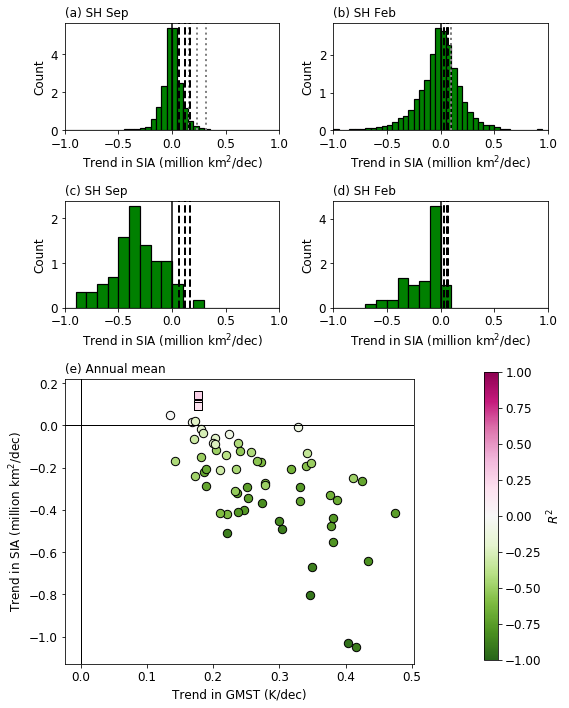

In [40]:
plt.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(8,10))

gs = gridspec.GridSpec(4, 4)

for m, month in enumerate([9,2]):
    ax1 = plt.subplot(gs[0, 2*m:(2*m+2)])
    
    mydata = [piCtrend_dict[f][m] for f in piCtrend_dict] #list of lists
    flatdata = [item for sublist in mydata for item in sublist]
    
    ax1.hist(flatdata, bins=np.linspace(-1,1,41),density=True,
             edgecolor='black',facecolor='green', linewidth=1.2)
    
    ax1.set_title(alph[m]+' SH '+months[month-1],loc='left',fontsize=12)
    ax1.axvline(x=0,c='black',linestyle='-')
    
    for o in range(3):
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope,c='black',linestyle='--',linewidth=2)
        print(months[month-1],' Trend in observations ',10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope.values,
             10.*obs_ds.isel(name=o).sel(month=month).sia_sh_1979to2014_slope.values)
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_1979to2014_slope,c='grey',linestyle=':',linewidth=2)
           
    ax1.set_xlim([-1,1])
    ax1.set_ylabel('Count')
    ax1.set_xlabel(r'Trend in SIA (million km$^2$/dec)')

    
for m, month in enumerate([9,2]):
    ax1 = plt.subplot(gs[1, 2*m:(2*m+2)])
   
    ax1.hist(10.*ensemble_ds.sia_sh_slope.sel(month=month), bins=np.linspace(-1,1,21),density=True,
             edgecolor='black',facecolor='green', linewidth=1.2)
    
    ax1.set_title(alph[m+2]+' SH '+months[month-1],loc='left',fontsize=12)
    ax1.axvline(x=0,c='black',linestyle='-')
    
    for o in range(3):
        ax1.axvline(x=10.*obs_ds.isel(name=o).sel(month=month).sia_sh_slope,c='black',linestyle='--',linewidth=2)
  
    ax1.set_xlim([-1,1])
    ax1.set_ylabel('Count')
    ax1.set_xlabel(r'Trend in SIA (million km$^2$/dec)')

    
ax = plt.subplot(gs[2:,:3])
ax.axhline(y=0,c='k',linewidth=1)
ax.axvline(x=0,c='k',linewidth=1)
correlation = []
for m in range(len(ensemble_ds.name.values)):

    bestfitx = np.arange(40)*ensemble_ds.gmst_slope.values[m]+ensemble_ds.gmst_intercept.values[m]
    xdata = ensemble_ds['gmst'].values[m,:]
    bestfity = np.arange(40)*ensemble_ds['sia_'+hemi+'_annmean_slope'].values[m] + ensemble_ds['sia_sh_annmean_intercept'].values[m]
    ydata = ensemble_ds['sia_sh'].mean(dim='month').values[m,:]#-bestfity


    if len(xdata[~np.isnan(xdata)])>2:
        corr, p = stats.pearsonr(xdata[~np.isnan(xdata)],
                                 ydata[~np.isnan(xdata)])

        fcolour = colours[int(100*corr+100)] 

    ax.scatter(10.*ensemble_ds['gmst_slope'][m],10.*ensemble_ds['sia_sh_annmean_slope'][m],
             s=70,edgecolors='black',facecolor=fcolour)

ax.set_xlabel('Trend in GMST (K/dec)',fontsize=12)
ax.set_ylabel('Trend in SIA (million km$^2$/dec)',fontsize=12)
ax.set_title('(e) Annual mean',loc='left',fontsize=12)

for o in range(3):
    fcolour = colours[int(100*obs_corr[h][o]+100)] 
    ax.scatter(10.*gmst_ds.gmst_slope.mean(), 10.*obs_ds['sia_sh_annmean_slope'].isel(name=o),
                 s=50,marker='s',edgecolors='black',facecolor=fcolour)

ax2  = fig.add_axes([0.85,0.075,0.025,0.4])
cmap = mpl.cm.PiYG_r
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
cb1 = mpl.colorbar.ColorbarBase(ax2, cmap=cmap,norm=norm,orientation='vertical')
cb1.set_label('$R^2$')
    
plt.tight_layout()
plt.show()
plt.close()

